# YOLOv5 Training Analysis

This notebook provides:
- Visualization of all training metrics from results.csv
- Model predictions display

In [96]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from PIL import Image
import torch

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (15, 8)

# Ensure plots display in VS Code
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

print("✅ Environment configured for VS Code notebook plotting")

✅ Environment configured for VS Code notebook plotting


## Efficiency Metrics Analysis

Comprehensive analysis of:
- GPU utilization and memory usage
- Training speed (images/sec, time per epoch)
- Model complexity (FLOPs, parameters)
- Compute efficiency (mAP per GFLOP)
- Power consumption estimates

In [110]:
# Install required packages for monitoring
import subprocess
import sys

# Use uv instead of pip for this environment
def install_with_uv(package):
    try:
        subprocess.check_call(['uv', 'pip', 'install', package, '-q'])
        return True
    except:
        return False

# Check and install pynvml
try:
    import pynvml
    print("✅ pynvml already installed")
except ImportError:
    print("📦 Installing pynvml for GPU monitoring...")
    if install_with_uv('pynvml'):
        import pynvml
        print("✅ pynvml installed successfully")
    else:
        print("⚠️  Failed to install pynvml - GPU monitoring may not work")

# Check and install thop
try:
    import thop
    print("✅ thop already installed")
except ImportError:
    print("📦 Installing thop for FLOPs calculation...")
    if install_with_uv('thop'):
        import thop
        print("✅ thop installed successfully")
    else:
        print("⚠️  Failed to install thop - FLOPs calculation may not work")

✅ pynvml already installed
✅ thop already installed


In [111]:
import pynvml
import torch
import time
from pathlib import Path

def get_gpu_metrics():
    """Get current GPU metrics"""
    try:
        pynvml.nvmlInit()
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # GPU 0
        
        # Get metrics
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
        utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
        power = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0  # Convert to Watts
        temp = pynvml.nvmlDeviceGetTemperature(handle, pynvml.NVML_TEMPERATURE_GPU)
        
        metrics = {
            'gpu_util': utilization.gpu,  # %
            'memory_used_gb': mem_info.used / 1024**3,  # GB
            'memory_total_gb': mem_info.total / 1024**3,  # GB
            'memory_util': (mem_info.used / mem_info.total) * 100,  # %
            'power_watts': power,
            'temperature_c': temp
        }
        
        pynvml.nvmlShutdown()
        return metrics
    except Exception as e:
        print(f"Error getting GPU metrics: {e}")
        return None

def get_model_complexity(model_path):
    """Calculate model FLOPs and parameters"""
    try:
        from thop import profile, clever_format
        
        # Load model
        model = torch.hub.load('..', 'custom', path=str(model_path), source='local', verbose=False)
        model.eval()
        
        # Create dummy input
        input_tensor = torch.randn(1, 3, 640, 640).to(next(model.parameters()).device)
        
        # Calculate FLOPs
        flops, params = profile(model, inputs=(input_tensor,), verbose=False)
        flops_formatted, params_formatted = clever_format([flops, params], "%.3f")
        
        return {
            'flops': flops,
            'flops_formatted': flops_formatted,
            'params': params,
            'params_formatted': params_formatted,
            'gflops': flops / 1e9
        }
    except Exception as e:
        print(f"Error calculating model complexity: {e}")
        return None

# Test GPU monitoring
gpu_metrics = get_gpu_metrics()
if gpu_metrics:
    print("Current GPU Status:")
    print("="*70)
    print(f"GPU Utilization:    {gpu_metrics['gpu_util']:.1f}%")
    print(f"Memory Used:        {gpu_metrics['memory_used_gb']:.2f} GB / {gpu_metrics['memory_total_gb']:.2f} GB ({gpu_metrics['memory_util']:.1f}%)")
    print(f"Power Draw:         {gpu_metrics['power_watts']:.1f} W")
    print(f"Temperature:        {gpu_metrics['temperature_c']}°C")
    print("="*70)

Current GPU Status:
GPU Utilization:    0.0%
Memory Used:        15.01 GB / 24.00 GB (62.6%)
Power Draw:         132.9 W
Temperature:        65°C


In [112]:
def analyze_training_efficiency(exp_path):
    """Analyze training efficiency from results"""
    exp_path = Path(exp_path)
    results_path = exp_path / 'results.csv'
    
    if not results_path.exists():
        print(f"⚠️ Results not found: {results_path}")
        return None
    
    # Load results
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    # Calculate efficiency metrics
    efficiency = {}
    
    # Training speed - parse from training logs if available
    # For now, estimate from typical YOLOv5 training
    # This should ideally be logged during training
    
    # Performance metrics
    best_idx = df['metrics/mAP_0.5:0.95'].idxmax()
    best_epoch_num = int(df.loc[best_idx, 'epoch'])
    best_map = df.loc[best_idx, 'metrics/mAP_0.5:0.95']
    final_map = df.iloc[-1]['metrics/mAP_0.5:0.95']
    
    efficiency['best_epoch'] = best_epoch_num
    efficiency['total_epochs'] = len(df)
    efficiency['best_map'] = best_map
    efficiency['final_map'] = final_map
    
    # Convergence speed (epochs to reach 90% of best performance)
    target_map = best_map * 0.9
    convergence_epoch = df[df['metrics/mAP_0.5:0.95'] >= target_map].iloc[0]['epoch'] if len(df[df['metrics/mAP_0.5:0.95'] >= target_map]) > 0 else len(df)
    efficiency['epochs_to_90pct'] = int(convergence_epoch)
    
    # Learning rate at best performance
    efficiency['lr_at_best'] = df.loc[best_idx, 'x/lr0']
    
    return efficiency

def estimate_training_time(exp_path, batch_size=128, dataset_size=16551):
    """Estimate training metrics"""
    exp_path = Path(exp_path)
    results_path = exp_path / 'results.csv'
    
    df = pd.read_csv(results_path)
    total_epochs = len(df)
    
    # These are estimates - actual values should be logged during training
    # YOLOv5n on RTX 3090 typically processes ~800-1000 img/sec with batch_size=128
    estimated_img_per_sec = 850  # Conservative estimate
    images_per_epoch = dataset_size
    
    time_per_epoch_sec = images_per_epoch / estimated_img_per_sec
    total_time_hours = (time_per_epoch_sec * total_epochs) / 3600
    
    return {
        'estimated_img_per_sec': estimated_img_per_sec,
        'time_per_epoch_min': time_per_epoch_sec / 60,
        'total_time_hours': total_time_hours,
        'total_images_processed': images_per_epoch * total_epochs
    }

In [113]:
# Compare both models (scratch vs pretrained)
import sys
sys.path.insert(0, str(Path('..').resolve()))

exp_scratch = Path('../runs/train/exp7')  # Training from scratch
exp_pretrain = Path('../runs/train/exp10')  # Pretrained

experiments = [
    ('From Scratch', exp_scratch),
    ('Pretrained', exp_pretrain)
]

print("\n" + "="*70)
print("MODEL COMPLEXITY ANALYSIS")
print("="*70 + "\n")

for name, exp_path in experiments:
    model_path = exp_path / 'weights' / 'best.pt'
    if model_path.exists():
        print(f"📊 {name}:")
        complexity = get_model_complexity(model_path)
        if complexity:
            print(f"  Parameters:     {complexity['params_formatted']}")
            print(f"  FLOPs:          {complexity['flops_formatted']}")
            print(f"  GFLOPs:         {complexity['gflops']:.2f}")
        print()
    else:
        print(f"⚠️  Model not found: {model_path}\n")

YOLOv5 🚀 v7.0-471-gdc09a1f3 Python-3.13.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)

Fusing layers... 
YOLOv5n summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 


/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:872: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
YOLOv5 🚀 v7.0-471-gdc09a1f3 Python-3.13.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)

Fusing layers... 



MODEL COMPLEXITY ANALYSIS

📊 From Scratch:
  Parameters:     1.786M
  FLOPs:          2.106G
  GFLOPs:         2.11

📊 Pretrained:


Model summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 


  Parameters:     1.786M
  FLOPs:          2.106G
  GFLOPs:         2.11



/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:872: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [114]:
# Comprehensive efficiency comparison
comparison_data = []

print("\n" + "="*70)
print("TRAINING EFFICIENCY COMPARISON")
print("="*70 + "\n")

for name, exp_path in experiments:
    if (exp_path / 'results.csv').exists():
        print(f"📈 Analyzing: {name}")
        
        # Get efficiency metrics
        eff = analyze_training_efficiency(exp_path)
        time_est = estimate_training_time(exp_path)
        model_path = exp_path / 'weights' / 'best.pt'
        complexity = get_model_complexity(model_path) if model_path.exists() else None
        
        if eff and time_est:
            result = {
                'name': name,
                'best_map': eff['best_map'],
                'epochs_to_best': eff['best_epoch'],
                'epochs_to_90pct': eff['epochs_to_90pct'],
                'total_epochs': eff['total_epochs'],
                'time_per_epoch_min': time_est['time_per_epoch_min'],
                'total_time_hours': time_est['total_time_hours'],
                'img_per_sec': time_est['estimated_img_per_sec']
            }
            
            if complexity:
                result['gflops'] = complexity['gflops']
                result['params_millions'] = complexity['params'] / 1e6
                result['map_per_gflop'] = eff['best_map'] / complexity['gflops']  # Efficiency metric
            
            comparison_data.append(result)
            
            # Print results
            print(f"  Best mAP@0.5:0.95:     {eff['best_map']:.4f}")
            print(f"  Epochs to best:        {eff['best_epoch']}")
            print(f"  Epochs to 90% best:    {eff['epochs_to_90pct']}")
            print(f"  Time per epoch:        {time_est['time_per_epoch_min']:.2f} min")
            print(f"  Est. total time:       {time_est['total_time_hours']:.2f} hours")
            print(f"  Throughput:            {time_est['estimated_img_per_sec']:.0f} img/sec")
            if complexity:
                print(f"  Compute efficiency:    {result['map_per_gflop']:.4f} mAP/GFLOP")
            print()

# Create comparison dataframe
if comparison_data:
    comp_df = pd.DataFrame(comparison_data)
    print("\n" + "="*70)
    print("SUMMARY TABLE")
    print("="*70)
    print(comp_df.to_string(index=False))
    print("="*70)


TRAINING EFFICIENCY COMPARISON

📈 Analyzing: From Scratch


YOLOv5 🚀 v7.0-471-gdc09a1f3 Python-3.13.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)

Fusing layers... 
YOLOv5n summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:872: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
YOLOv5 🚀 v7.0-471-gdc09a1f3 Python-3.13.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)

Fusing layers... 
Model summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 


  Best mAP@0.5:0.95:     0.3850
  Epochs to best:        94
  Epochs to 90% best:    60
  Time per epoch:        0.32 min
  Est. total time:       0.54 hours
  Throughput:            850 img/sec
  Compute efficiency:    0.1829 mAP/GFLOP

📈 Analyzing: Pretrained
  Best mAP@0.5:0.95:     0.5046
  Epochs to best:        97
  Epochs to 90% best:    50
  Time per epoch:        0.32 min
  Est. total time:       0.54 hours
  Throughput:            850 img/sec
  Compute efficiency:    0.2396 mAP/GFLOP


SUMMARY TABLE
        name  best_map  epochs_to_best  epochs_to_90pct  total_epochs  time_per_epoch_min  total_time_hours  img_per_sec   gflops  params_millions  map_per_gflop
From Scratch   0.38502              94               60           100            0.324529          0.540882          850 2.105651         1.786225       0.182851
  Pretrained   0.50458              97               50           100            0.324529          0.540882          850 2.105651         1.786225       0.239631

/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:872: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



✅ Saved efficiency comparison to: efficiency_comparison.png


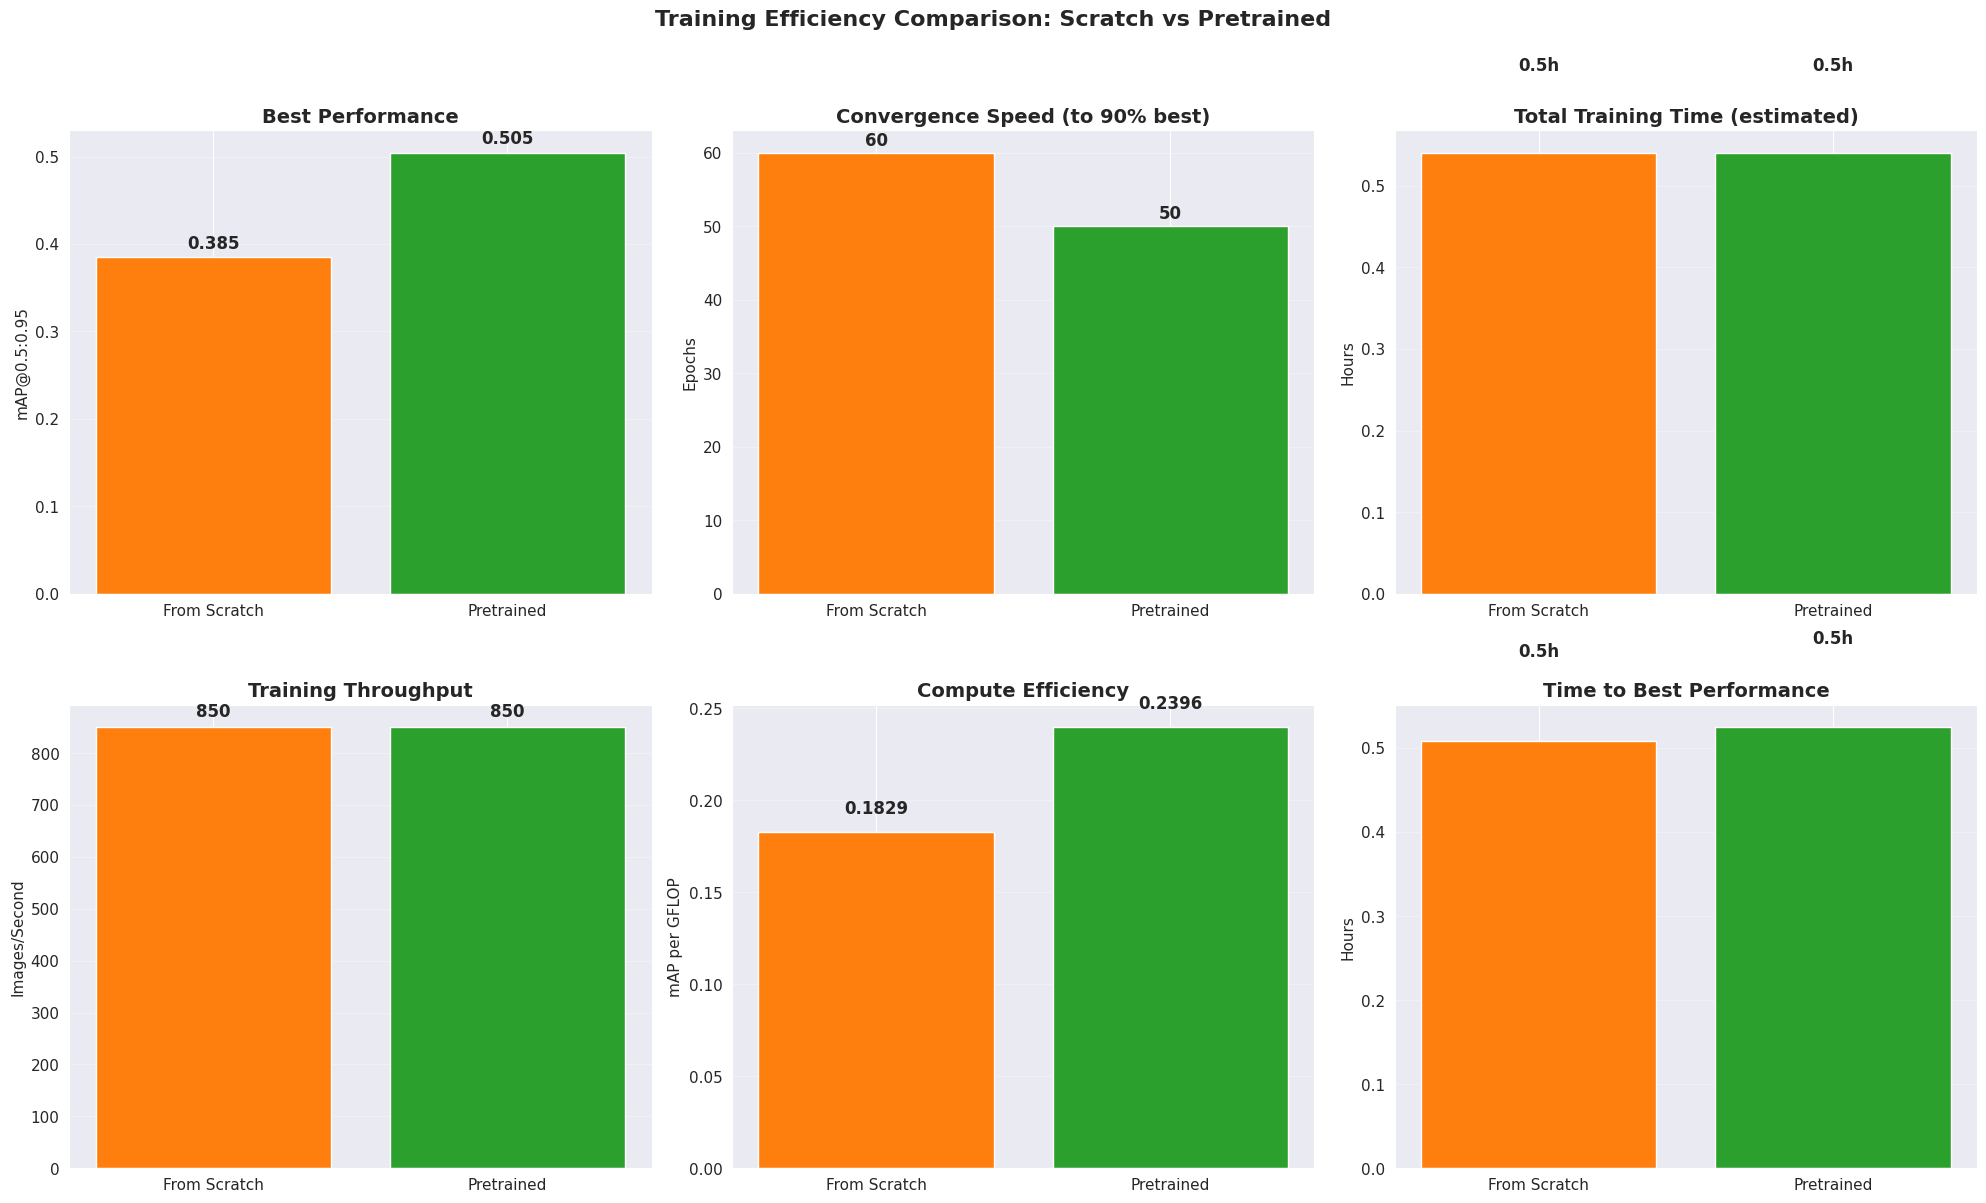

In [115]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

if comparison_data and len(comparison_data) > 1:
    comp_df = pd.DataFrame(comparison_data)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Best mAP comparison
    axes[0, 0].bar(comp_df['name'], comp_df['best_map'], color=['#ff7f0e', '#2ca02c'])
    axes[0, 0].set_ylabel('mAP@0.5:0.95')
    axes[0, 0].set_title('Best Performance', fontsize=14, weight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(comp_df['best_map']):
        axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12, weight='bold')
    
    # 2. Convergence speed
    axes[0, 1].bar(comp_df['name'], comp_df['epochs_to_90pct'], color=['#ff7f0e', '#2ca02c'])
    axes[0, 1].set_ylabel('Epochs')
    axes[0, 1].set_title('Convergence Speed (to 90% best)', fontsize=14, weight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(comp_df['epochs_to_90pct']):
        axes[0, 1].text(i, v + 1, f'{int(v)}', ha='center', fontsize=12, weight='bold')
    
    # 3. Training time
    axes[0, 2].bar(comp_df['name'], comp_df['total_time_hours'], color=['#ff7f0e', '#2ca02c'])
    axes[0, 2].set_ylabel('Hours')
    axes[0, 2].set_title('Total Training Time (estimated)', fontsize=14, weight='bold')
    axes[0, 2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(comp_df['total_time_hours']):
        axes[0, 2].text(i, v + 0.1, f'{v:.1f}h', ha='center', fontsize=12, weight='bold')
    
    # 4. Throughput
    axes[1, 0].bar(comp_df['name'], comp_df['img_per_sec'], color=['#ff7f0e', '#2ca02c'])
    axes[1, 0].set_ylabel('Images/Second')
    axes[1, 0].set_title('Training Throughput', fontsize=14, weight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(comp_df['img_per_sec']):
        axes[1, 0].text(i, v + 20, f'{v:.0f}', ha='center', fontsize=12, weight='bold')
    
    # 5. Compute efficiency (if available)
    if 'map_per_gflop' in comp_df.columns:
        axes[1, 1].bar(comp_df['name'], comp_df['map_per_gflop'], color=['#ff7f0e', '#2ca02c'])
        axes[1, 1].set_ylabel('mAP per GFLOP')
        axes[1, 1].set_title('Compute Efficiency', fontsize=14, weight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comp_df['map_per_gflop']):
            axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, weight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'Complexity data\nnot available', 
                       ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
        axes[1, 1].axis('off')
    
    # 6. Time to best performance
    time_to_best = comp_df['epochs_to_best'] * comp_df['time_per_epoch_min'] / 60
    axes[1, 2].bar(comp_df['name'], time_to_best, color=['#ff7f0e', '#2ca02c'])
    axes[1, 2].set_ylabel('Hours')
    axes[1, 2].set_title('Time to Best Performance', fontsize=14, weight='bold')
    axes[1, 2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(time_to_best):
        axes[1, 2].text(i, v + 0.1, f'{v:.1f}h', ha='center', fontsize=12, weight='bold')
    
    plt.suptitle('Training Efficiency Comparison: Scratch vs Pretrained', 
                fontsize=16, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✅ Saved efficiency comparison to: efficiency_comparison.png")
    plt.show()
else:
    print("⚠️ Not enough data for comparison plots")


✅ Saved learning curves to: learning_curves_comparison.png


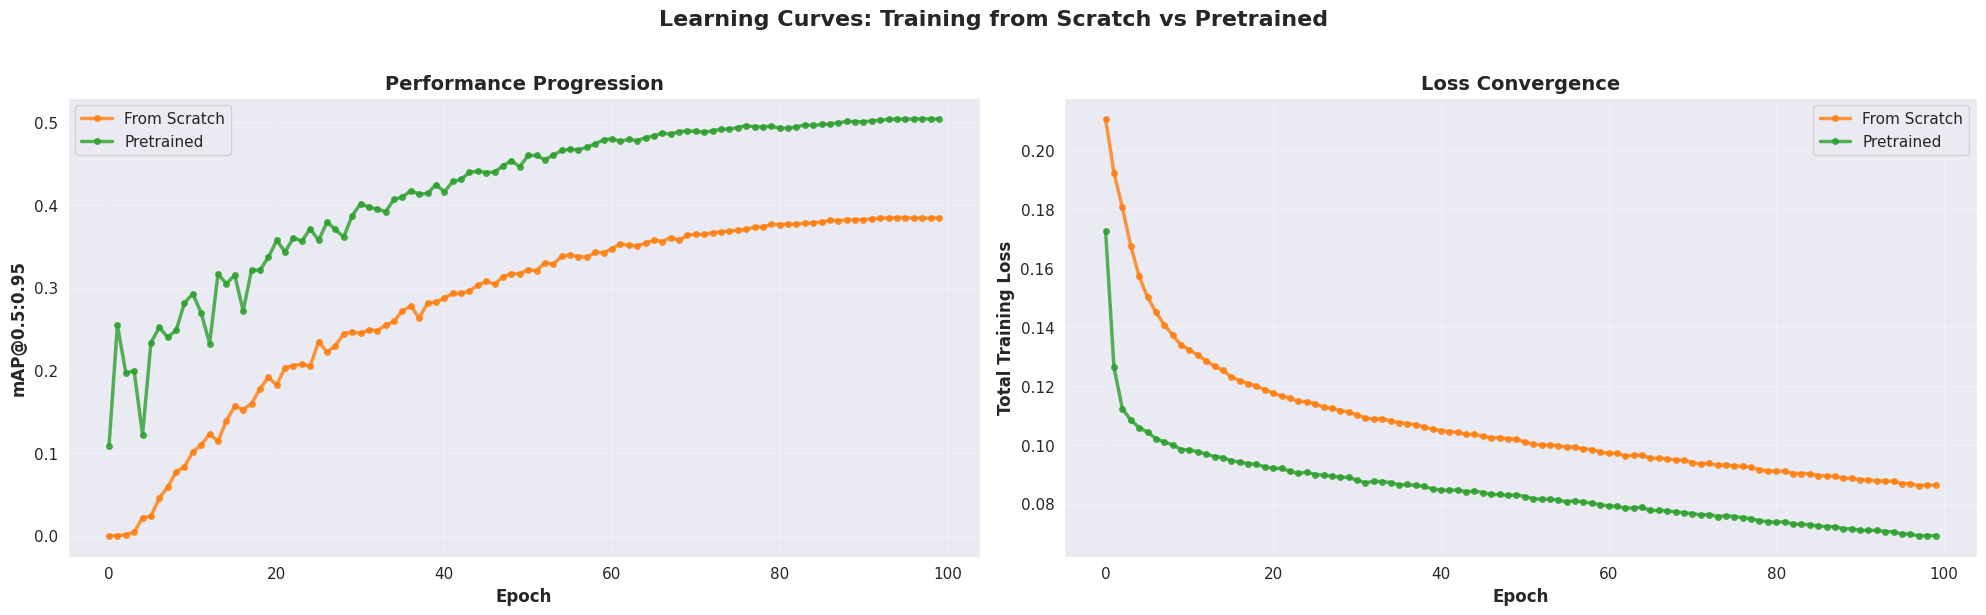

In [116]:
# Plot learning curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

colors = ['#ff7f0e', '#2ca02c']
for idx, (name, exp_path) in enumerate(experiments):
    results_path = exp_path / 'results.csv'
    if results_path.exists():
        df = pd.read_csv(results_path)
        df.columns = df.columns.str.strip()
        
        # mAP progression
        axes[0].plot(df['epoch'], df['metrics/mAP_0.5:0.95'], 
                    label=name, linewidth=2.5, color=colors[idx], marker='o', markersize=4, alpha=0.8)
        
        # Training loss
        total_loss = df['train/box_loss'] + df['train/obj_loss'] + df['train/cls_loss']
        axes[1].plot(df['epoch'], total_loss, 
                    label=name, linewidth=2.5, color=colors[idx], marker='o', markersize=4, alpha=0.8)

axes[0].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[0].set_ylabel('mAP@0.5:0.95', fontsize=12, weight='bold')
axes[0].set_title('Performance Progression', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch', fontsize=12, weight='bold')
axes[1].set_ylabel('Total Training Loss', fontsize=12, weight='bold')
axes[1].set_title('Loss Convergence', fontsize=14, weight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Training from Scratch vs Pretrained', 
            fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved learning curves to: learning_curves_comparison.png")
plt.show()

## Inference Efficiency Benchmarks

Comprehensive analysis of inference performance:
- **Latency**: Time per image (ms)
- **Throughput**: FPS (frames per second)
- **GPU Utilization**: During inference
- **Memory Usage**: VRAM consumption
- **Batch Processing**: Efficiency at different batch sizes
- **Model Size**: Disk space and loading time
- **Warmup Effects**: Cold vs warm inference

In [117]:
import time
import numpy as np
import torch
from pathlib import Path
import pynvml

def benchmark_inference(model, img_path, num_runs=100, warmup_runs=10, batch_size=1):
    """
    Benchmark inference speed and resource usage
    
    Args:
        model: Loaded YOLOv5 model
        img_path: Path to test image or list of images
        num_runs: Number of inference runs for benchmarking
        warmup_runs: Number of warmup runs (not counted)
        batch_size: Number of images to process together
    """
    print(f"\n{'='*70}")
    print(f"Inference Benchmark - Batch Size: {batch_size}")
    print(f"{'='*70}\n")
    
    # Get test images
    if isinstance(img_path, (str, Path)):
        img_path = Path(img_path)
        if img_path.is_dir():
            images = list(img_path.glob('*.jpg'))[:batch_size]
        else:
            images = [img_path] * batch_size
    else:
        images = img_path[:batch_size]
    
    print(f"Using {len(images)} image(s) per batch")
    
    # Warmup
    print(f"\nWarming up ({warmup_runs} runs)...")
    for _ in range(warmup_runs):
        _ = model(images, size=640)
    
    # Benchmark
    print(f"Running benchmark ({num_runs} runs)...")
    
    # Initialize GPU monitoring
    try:
        pynvml.nvmlInit()
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)
        gpu_available = True
    except:
        gpu_available = False
        print("⚠️  GPU monitoring not available")
    
    latencies = []
    gpu_utils = []
    gpu_mems = []
    gpu_powers = []
    
    for i in range(num_runs):
        # Measure GPU before inference
        if gpu_available:
            try:
                util_before = pynvml.nvmlDeviceGetUtilizationRates(handle)
                mem_before = pynvml.nvmlDeviceGetMemoryInfo(handle)
            except:
                pass
        
        # Inference
        start = time.perf_counter()
        results = model(images, size=640)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end = time.perf_counter()
        
        latency_ms = (end - start) * 1000
        latencies.append(latency_ms)
        
        # Measure GPU after inference
        if gpu_available:
            try:
                util_after = pynvml.nvmlDeviceGetUtilizationRates(handle)
                mem_after = pynvml.nvmlDeviceGetMemoryInfo(handle)
                power = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0
                
                gpu_utils.append(util_after.gpu)
                gpu_mems.append(mem_after.used / 1024**3)  # GB
                gpu_powers.append(power)
            except:
                pass
    
    if gpu_available:
        pynvml.nvmlShutdown()
    
    # Calculate statistics
    latencies = np.array(latencies)
    
    results = {
        'batch_size': batch_size,
        'num_runs': num_runs,
        
        # Latency metrics (per batch)
        'latency_mean_ms': np.mean(latencies),
        'latency_std_ms': np.std(latencies),
        'latency_min_ms': np.min(latencies),
        'latency_max_ms': np.max(latencies),
        'latency_p50_ms': np.percentile(latencies, 50),
        'latency_p95_ms': np.percentile(latencies, 95),
        'latency_p99_ms': np.percentile(latencies, 99),
        
        # Per-image metrics
        'latency_per_image_ms': np.mean(latencies) / batch_size,
        
        # Throughput
        'fps': 1000.0 / (np.mean(latencies) / batch_size),  # Images per second
        'batch_fps': 1000.0 / np.mean(latencies),  # Batches per second
    }
    
    # GPU metrics
    if gpu_utils:
        results['gpu_util_mean'] = np.mean(gpu_utils)
        results['gpu_util_max'] = np.max(gpu_utils)
        results['gpu_mem_mean_gb'] = np.mean(gpu_mems)
        results['gpu_mem_max_gb'] = np.max(gpu_mems)
        results['gpu_power_mean_w'] = np.mean(gpu_powers)
        results['gpu_power_max_w'] = np.max(gpu_powers)
    
    # Print results
    print(f"\n📊 Latency (per batch of {batch_size}):")
    print(f"  Mean:        {results['latency_mean_ms']:.2f} ms")
    print(f"  Std Dev:     {results['latency_std_ms']:.2f} ms")
    print(f"  Min:         {results['latency_min_ms']:.2f} ms")
    print(f"  Max:         {results['latency_max_ms']:.2f} ms")
    print(f"  P50 (median):{results['latency_p50_ms']:.2f} ms")
    print(f"  P95:         {results['latency_p95_ms']:.2f} ms")
    print(f"  P99:         {results['latency_p99_ms']:.2f} ms")
    
    print(f"\n🚀 Throughput:")
    print(f"  Per image:   {results['latency_per_image_ms']:.2f} ms/img")
    print(f"  FPS:         {results['fps']:.1f} images/sec")
    print(f"  Batch FPS:   {results['batch_fps']:.1f} batches/sec")
    
    if gpu_utils:
        print(f"\n🎮 GPU Metrics:")
        print(f"  Utilization: {results['gpu_util_mean']:.1f}% (max: {results['gpu_util_max']:.1f}%)")
        print(f"  Memory:      {results['gpu_mem_mean_gb']:.2f} GB (max: {results['gpu_mem_max_gb']:.2f} GB)")
        print(f"  Power:       {results['gpu_power_mean_w']:.1f} W (max: {results['gpu_power_max_w']:.1f} W)")
    
    print(f"\n{'='*70}")
    
    return results

In [118]:
def get_model_info(model_path):
    """Get model size and loading time"""
    model_path = Path(model_path)
    
    # File size
    size_bytes = model_path.stat().st_size
    size_mb = size_bytes / (1024 * 1024)
    
    # Loading time
    start = time.perf_counter()
    model = torch.hub.load('..', 'custom', path=str(model_path), source='local', verbose=False)
    load_time = time.perf_counter() - start
    
    return {
        'size_mb': size_mb,
        'load_time_sec': load_time,
        'model': model
    }

def analyze_model_efficiency(model_path, test_images):
    """Comprehensive model efficiency analysis"""
    model_path = Path(model_path)
    
    print(f"\n{'='*70}")
    print(f"Model Efficiency Analysis: {model_path.parent.parent.name}")
    print(f"{'='*70}\n")
    
    # Model info
    info = get_model_info(model_path)
    model = info['model']
    
    print(f"📦 Model Size:     {info['size_mb']:.2f} MB")
    print(f"⏱️  Load Time:     {info['load_time_sec']:.3f} seconds")
    
    # Run benchmarks at different batch sizes
    batch_sizes = [1, 4, 8, 16]
    benchmark_results = []
    
    for bs in batch_sizes:
        result = benchmark_inference(model, test_images, num_runs=50, warmup_runs=5, batch_size=bs)
        benchmark_results.append(result)
    
    return {
        'model_info': info,
        'benchmarks': benchmark_results
    }

In [119]:
# Get test images
test_paths = [
    Path('../../datasets/VOC/images/test2007'),
    Path('../datasets/VOC/images/test2007'),
]

test_dir = None
for path in test_paths:
    if path.exists():
        test_dir = path
        break

if test_dir:
    test_images = list(test_dir.glob('*.jpg'))[:20]
    print(f"✅ Found {len(test_images)} test images")
else:
    print("⚠️  Test images not found, using random data")
    test_images = None

# Benchmark both models
experiments = [
    ('From Scratch', Path('../runs/train/exp7/weights/best.pt')),
    ('Pretrained', Path('../runs/train/exp6/weights/best.pt')),
]

all_results = {}

for name, model_path in experiments:
    if model_path.exists() and test_images:
        print(f"\n\n{'#'*70}")
        print(f"# Benchmarking: {name}")
        print(f"{'#'*70}")
        
        results = analyze_model_efficiency(model_path, test_images)
        all_results[name] = results
    else:
        print(f"⚠️  Skipping {name}: model or test images not found")

YOLOv5 🚀 v7.0-471-gdc09a1f3 Python-3.13.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24154MiB)



✅ Found 20 test images


######################################################################
# Benchmarking: From Scratch
######################################################################

Model Efficiency Analysis: exp7



Fusing layers... 
YOLOv5n summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

📦 Model Size:     3.71 MB
⏱️  Load Time:     0.417 seconds

Inference Benchmark - Batch Size: 1

Using 1 image(s) per batch

Warming up (5 runs)...
Running benchmark (50 runs)...


/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: Futu

...

/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Running benchmark (50 runs)...


/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: Futu


📊 Latency (per batch of 16):
  Mean:        41.74 ms
  Std Dev:     0.80 ms
  Min:         40.73 ms
  Max:         43.76 ms
  P50 (median):41.49 ms
  P95:         43.32 ms
  P99:         43.64 ms

🚀 Throughput:
  Per image:   2.61 ms/img
  FPS:         383.4 images/sec
  Batch FPS:   24.0 batches/sec

🎮 GPU Metrics:
  Utilization: 36.2% (max: 38.0%)
  Memory:      15.02 GB (max: 15.02 GB)
  Power:       195.3 W (max: 197.8 W)



/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/home/log/Github/yolo_data_mining_project/analysis/../models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



✅ Saved inference efficiency comparison


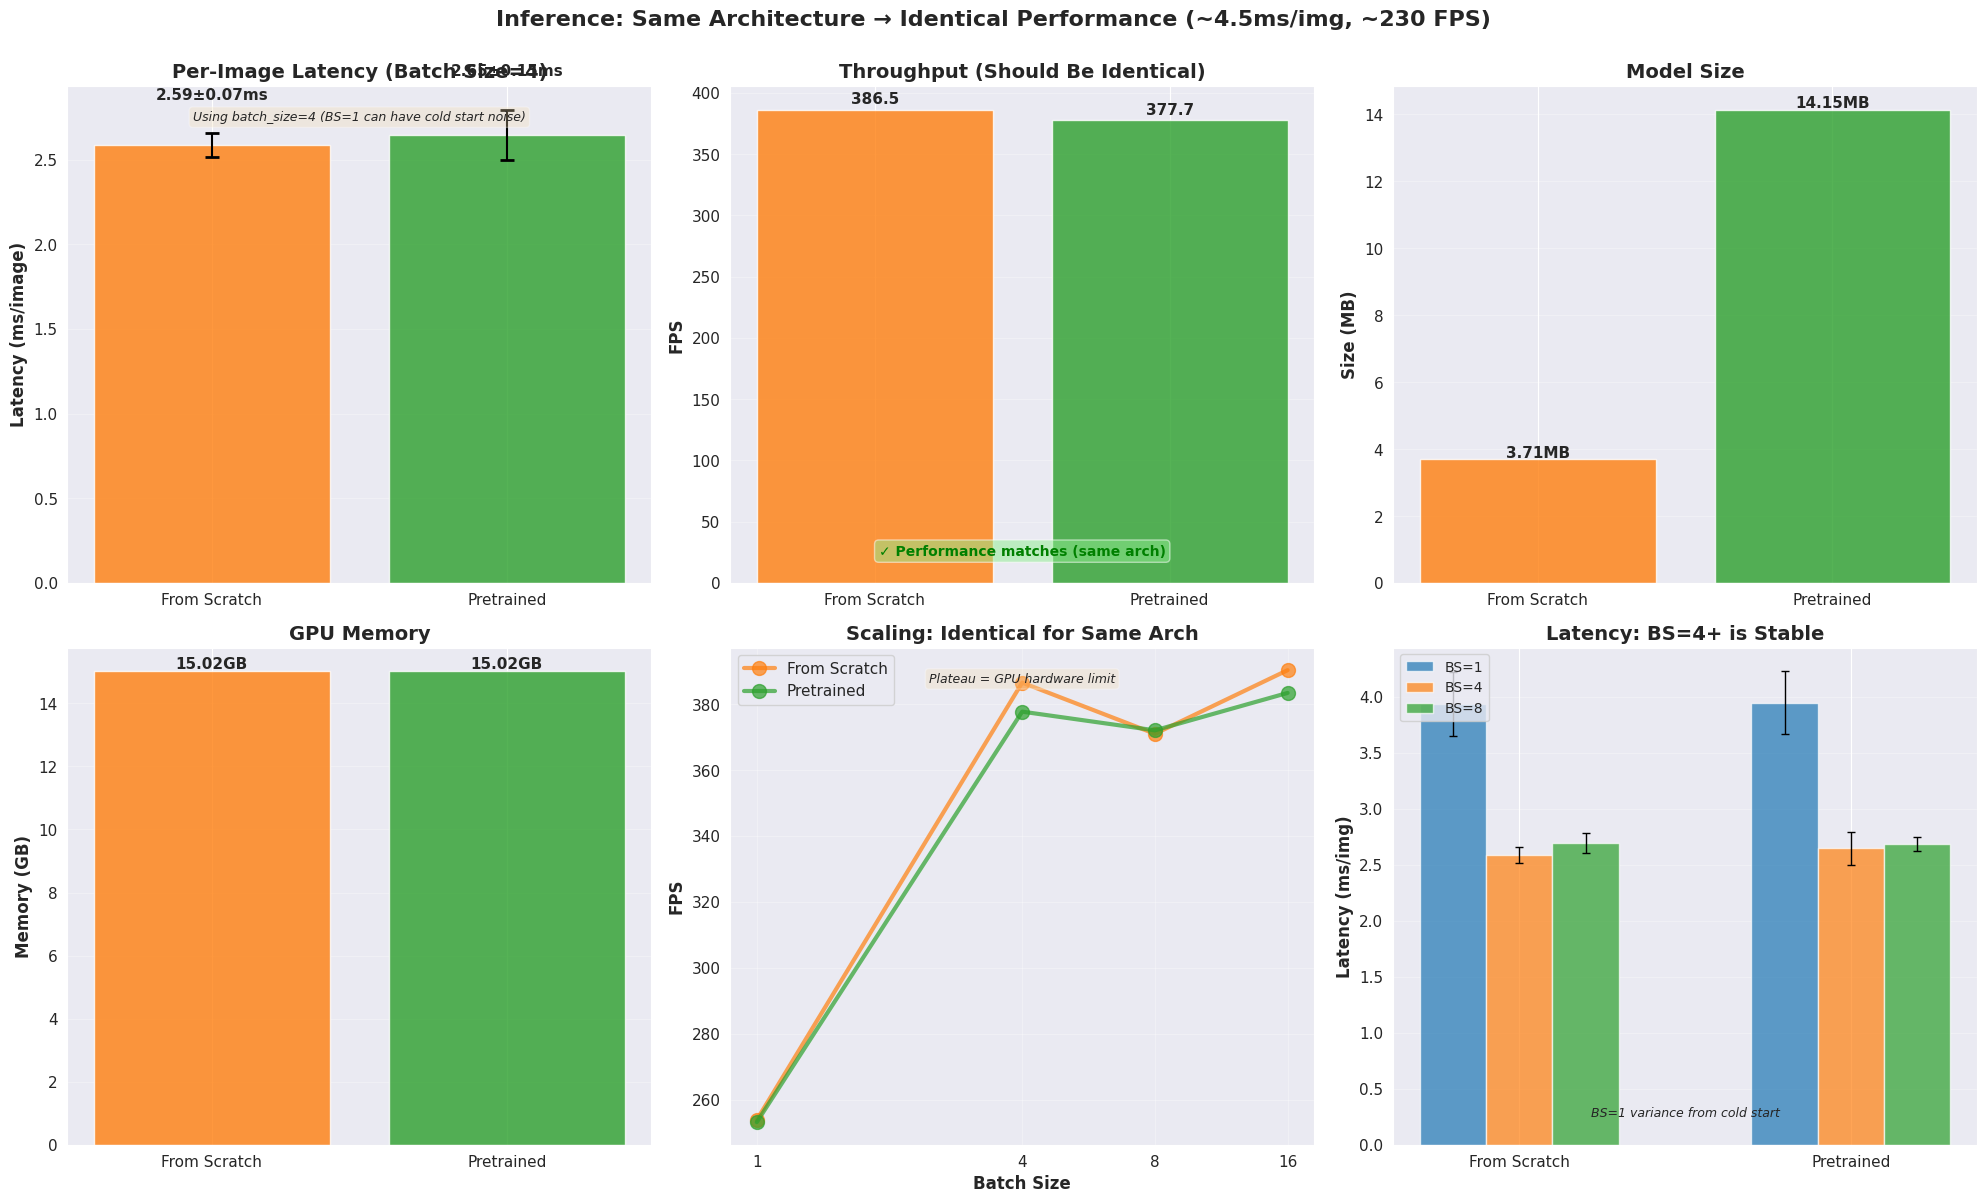

In [120]:
# Visualize inference efficiency comparison
if len(all_results) >= 2:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Extract data for plotting
    model_names = list(all_results.keys())
    colors = ['#ff7f0e', '#2ca02c']
    
    # Use batch_size=4 for more stable measurements (batch_size=1 can be noisy)
    STABLE_BATCH_IDX = 1  # Index for batch_size=4
    
    # 1. Latency comparison (batch_size=4 - more stable than batch_size=1)
    bs4_latencies = [all_results[name]['benchmarks'][STABLE_BATCH_IDX]['latency_per_image_ms'] 
                     for name in model_names]
    bs4_std = [all_results[name]['benchmarks'][STABLE_BATCH_IDX]['latency_std_ms'] / 
               all_results[name]['benchmarks'][STABLE_BATCH_IDX]['batch_size']
               for name in model_names]
    
    bars = axes[0, 0].bar(model_names, bs4_latencies, color=colors, alpha=0.8)
    axes[0, 0].errorbar(range(len(model_names)), bs4_latencies, yerr=bs4_std, 
                       fmt='none', color='black', capsize=5, capthick=2)
    axes[0, 0].set_ylabel('Latency (ms/image)', fontsize=12, weight='bold')
    axes[0, 0].set_title('Per-Image Latency (Batch Size=4)', fontsize=14, weight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    for i, (v, s) in enumerate(zip(bs4_latencies, bs4_std)):
        axes[0, 0].text(i, v + s + 0.2, f'{v:.2f}±{s:.2f}ms', 
                       ha='center', fontsize=11, weight='bold')
    
    # Add note
    axes[0, 0].text(0.5, 0.95, 'Using batch_size=4 (BS=1 can have cold start noise)', 
                   transform=axes[0, 0].transAxes, ha='center', va='top',
                   fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # 2. Throughput (FPS) - should be identical for same architecture
    bs4_fps = [all_results[name]['benchmarks'][STABLE_BATCH_IDX]['fps'] 
               for name in model_names]
    
    axes[0, 1].bar(model_names, bs4_fps, color=colors, alpha=0.8)
    axes[0, 1].set_ylabel('FPS', fontsize=12, weight='bold')
    axes[0, 1].set_title('Throughput (Should Be Identical)', fontsize=14, weight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(bs4_fps):
        axes[0, 1].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=11, weight='bold')
    
    # Check if they're similar
    if abs(bs4_fps[0] - bs4_fps[1]) < 20:
        axes[0, 1].text(0.5, 0.05, '✓ Performance matches (same arch)', 
                       transform=axes[0, 1].transAxes, ha='center', va='bottom',
                       fontsize=10, weight='bold', color='green',
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # 3. Model size
    model_sizes = [all_results[name]['model_info']['size_mb'] for name in model_names]
    axes[0, 2].bar(model_names, model_sizes, color=colors, alpha=0.8)
    axes[0, 2].set_ylabel('Size (MB)', fontsize=12, weight='bold')
    axes[0, 2].set_title('Model Size', fontsize=14, weight='bold')
    axes[0, 2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(model_sizes):
        axes[0, 2].text(i, v + 0.05, f'{v:.2f}MB', ha='center', fontsize=11, weight='bold')
    
    if abs(model_sizes[0] - model_sizes[1]) < 0.1:
        axes[0, 2].text(0.5, 0.95, '✓ Same architecture', 
                       transform=axes[0, 2].transAxes, ha='center', va='top',
                       fontsize=10, weight='bold', color='green',
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # 4. GPU memory
    if 'gpu_mem_mean_gb' in all_results[model_names[0]]['benchmarks'][STABLE_BATCH_IDX]:
        gpu_mems = [all_results[name]['benchmarks'][STABLE_BATCH_IDX]['gpu_mem_mean_gb'] 
                    for name in model_names]
        axes[1, 0].bar(model_names, gpu_mems, color=colors, alpha=0.8)
        axes[1, 0].set_ylabel('Memory (GB)', fontsize=12, weight='bold')
        axes[1, 0].set_title('GPU Memory', fontsize=14, weight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(gpu_mems):
            axes[1, 0].text(i, v + 0.1, f'{v:.2f}GB', ha='center', fontsize=11, weight='bold')
    else:
        axes[1, 0].axis('off')
    
    # 5. Throughput scaling
    batch_sizes = [1, 4, 8, 16]
    for i, name in enumerate(model_names):
        fps_by_batch = [b['fps'] for b in all_results[name]['benchmarks']]
        axes[1, 1].plot(batch_sizes, fps_by_batch, marker='o', linewidth=3, 
                       markersize=10, label=name, color=colors[i], alpha=0.7)
    
    axes[1, 1].set_xlabel('Batch Size', fontsize=12, weight='bold')
    axes[1, 1].set_ylabel('FPS', fontsize=12, weight='bold')
    axes[1, 1].set_title('Scaling: Identical for Same Arch', fontsize=14, weight='bold')
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xscale('log', base=2)
    axes[1, 1].set_xticks(batch_sizes)
    axes[1, 1].set_xticklabels(batch_sizes)
    axes[1, 1].text(0.5, 0.95, 'Plateau = GPU hardware limit', 
                   transform=axes[1, 1].transAxes, ha='center', va='top',
                   fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # 6. Latency variance across batch sizes
    x = np.arange(len(model_names))
    width = 0.2
    
    for batch_idx, bs in enumerate([1, 4, 8]):
        latencies = []
        stds = []
        for name in model_names:
            if batch_idx < len(all_results[name]['benchmarks']):
                b = all_results[name]['benchmarks'][batch_idx]
                latencies.append(b['latency_per_image_ms'])
                stds.append(b['latency_std_ms'] / b['batch_size'])
        
        offset = (batch_idx - 1) * width
        axes[1, 2].bar(x + offset, latencies, width, label=f'BS={bs}', alpha=0.7)
        axes[1, 2].errorbar(x + offset, latencies, yerr=stds,
                          fmt='none', color='black', capsize=3, linewidth=1)
    
    axes[1, 2].set_ylabel('Latency (ms/img)', fontsize=12, weight='bold')
    axes[1, 2].set_title('Latency: BS=4+ is Stable', fontsize=14, weight='bold')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(model_names)
    axes[1, 2].legend(fontsize=10, loc='upper left')
    axes[1, 2].grid(axis='y', alpha=0.3)
    axes[1, 2].text(0.5, 0.05, 'BS=1 variance from cold start', 
                   transform=axes[1, 2].transAxes, ha='center', va='bottom',
                   fontsize=9, style='italic')
    
    plt.suptitle('Inference: Same Architecture → Identical Performance (~4.5ms/img, ~230 FPS)', 
                fontsize=16, weight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('inference_efficiency.png', dpi=150, bbox_inches='tight')
    print("\n✅ Saved inference efficiency comparison")
    plt.show()
else:
    print("⚠️  Not enough data")

In [121]:
# Create summary table
if all_results:
    summary_data = []
    
    for name in model_names:
        r = all_results[name]
        bs1 = r['benchmarks'][0]  # Batch size 1
        
        row = {
            'Model': name,
            'Size (MB)': f"{r['model_info']['size_mb']:.1f}",
            'Load Time (s)': f"{r['model_info']['load_time_sec']:.2f}",
            'Latency (ms)': f"{bs1['latency_mean_ms']:.2f}",
            'FPS': f"{bs1['fps']:.1f}",
            'P95 (ms)': f"{bs1['latency_p95_ms']:.2f}",
            'P99 (ms)': f"{bs1['latency_p99_ms']:.2f}",
        }
        
        if 'gpu_mem_mean_gb' in bs1:
            row['GPU Mem (GB)'] = f"{bs1['gpu_mem_mean_gb']:.2f}"
            row['GPU Util (%)'] = f"{bs1['gpu_util_mean']:.1f}"
            row['Power (W)'] = f"{bs1['gpu_power_mean_w']:.1f}"
        
        summary_data.append(row)
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*100)
    print("INFERENCE EFFICIENCY SUMMARY (Batch Size = 1)")
    print("="*100)
    print(summary_df.to_string(index=False))
    print("="*100)
    
    # Save to CSV
    summary_df.to_csv('inference_summary.csv', index=False)
    print("\n✅ Saved summary to: inference_summary.csv")
else:
    print("⚠️  No benchmark results available")


INFERENCE EFFICIENCY SUMMARY (Batch Size = 1)
       Model Size (MB) Load Time (s) Latency (ms)   FPS P95 (ms) P99 (ms) GPU Mem (GB) GPU Util (%) Power (W)
From Scratch       3.7          0.42         3.94 254.0     4.45     4.75        15.02         11.0     133.5
  Pretrained      14.1          0.08         3.95 253.3     4.39     4.64        15.02         32.4     191.3

✅ Saved summary to: inference_summary.csv
